#### Results 5.3 — pedagogical alignment of the base, SFT and DPO models (RQ2, RQ3)

Sources, all read only (nothing of the SFT / DPO stage is executed):
- the gpt-4.1-mini judge labels of the five models (base, SFT, DPO 10 / 30 / 50 %), 298 test contexts each
- the SFT / DPO training logs (last checkpoint of each run)
- the 24,298 preference pairs of the DPO runs (selection and 80:20 split as in the DPO notebooks)

Outputs: PDF + PNG per figure and one CSV per table; the LaTeX of Section 5.3 reads them from the thesis figure folder. Captions live in LaTeX, not in the figures.

Figure numbers continue Chapter 5: 5.7 DAMR per dimension, 5.8 judge label distribution, 5.9 DAMR per error type,
5.10 change vs. SFT per error type, 5.11 preference signal per error type, 5.12 change vs. SFT grouped by the move the pairs favour;
A.1 training behaviour (supplementary, not in the text).

Everything in Section 5.3 is measured with DAMR (judge labels) or with the classifier posteriors of the preference pairs;
no additional surface measure of the responses is used.

Only pandas, numpy and matplotlib are needed (scikit-learn for cell 6b).


#### 0. Setup — paths, names, colours

In [1]:
from pathlib import Path
import json
import os
import re
import tempfile
import textwrap

# writable matplotlib cache; nothing needs to be installed
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "result_5_3_mpl_cache"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# repository root = folder that contains 2__SFT_DPO__ (this notebook sits in figure_notebooks/, one level below)
ROOT = Path.cwd()
if not (ROOT / "2__SFT_DPO__").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "2__SFT_DPO__").is_dir(), "Set ROOT to the final thesis repository."

SFT_DPO = ROOT / "2__SFT_DPO__"
EVAL_DIR = SFT_DPO / "pedagogy_evaluation"   # pedagogy_eval_{base,sft,dpo_01,dpo_03,dpo_05}.csv: judge labels, 298 test contexts x 5 models
PAIRS_FILE = (SFT_DPO / "data_preference_train_only"
              / "bridge_2tage__with_reference_solution_more_models" / "response_pairs_df.csv")   # the 24,298 preference pairs
# last checkpoint of every run keeps the whole log history (loss every 25 steps, validation every 200)
TRAINER_STATE = {
    "sft":    SFT_DPO / "llama3-8b-instruct-sft-adapter/checkpoint-1521/trainer_state.json",
    "dpo_01": SFT_DPO / "llama3-8b-instruct-dpo-adapter--threshold_01/checkpoint-366/trainer_state.json",
    "dpo_03": SFT_DPO / "llama3-8b-instruct-dpo-adapter--threshold_03/checkpoint-1095/trainer_state.json",
    "dpo_05": SFT_DPO / "llama3-8b-instruct-dpo-adapter--threshold_05/checkpoint-1824/trainer_state.json",
}
OUT = Path(os.environ.get("RESULT_5_3_OUTPUT_DIR", ROOT / "result_5_3_figures"))   # PDF + PNG per figure, CSV per table
OUT.mkdir(parents=True, exist_ok=True)

# five model variants in pipeline order; rho = share of pairs kept per error type
MODELS = ["base", "sft", "dpo_01", "dpo_03", "dpo_05"]
MODEL_NAMES = {"base": "Base", "sft": "SFT", "dpo_01": "DPO 10%", "dpo_03": "DPO 30%", "dpo_05": "DPO 50%"}
DPO_MODELS = ["dpo_01", "dpo_03", "dpo_05"]
RHO = {"dpo_01": 0.1, "dpo_03": 0.3, "dpo_05": 0.5}

# eight dimensions of Table 4.10 and the desired judge label of each
DIMS = ["mistake_identification", "mistake_location", "revealing_answer", "providing_guidance",
        "actionability", "coherence", "tutor_tone", "human_likeness"]
DIM_NAMES = {
    "mistake_identification": "Mistake identification",
    "mistake_location": "Mistake location",
    "revealing_answer": "Revealing the answer",
    "providing_guidance": "Providing guidance",
    "actionability": "Actionability",
    "coherence": "Coherence",
    "tutor_tone": "Tutor tone",
    "human_likeness": "Human-likeness",
}
DESIRED = {dim: "Yes" for dim in DIMS}
DESIRED["revealing_answer"] = "No"
DESIRED["tutor_tone"] = "Encouraging"
# label order for the stacked bars: desired label first
LABELS = {dim: ["Yes", "To some extent", "No"] for dim in DIMS}
LABELS["revealing_answer"] = ["No", "Yes (correct)", "Yes (incorrect)"]
LABELS["coherence"] = ["Yes", "No"]
LABELS["human_likeness"] = ["Yes", "To some extent", "No"]
LABELS["tutor_tone"] = ["Encouraging", "Neutral", "Offensive"]

# error types: order and names as in result_5_2.ipynb (order of the Chapter 4 tables, names of Section 4.2)
ERRORS = [
    "calculation_error_easily_solved_by_a_calculator",
    "extra_quantity_or_missing_quantity",
    "missing_wrong_factual_knowledge",
    "misunderstanding_of_a_question",
    "none_of_the_above",
    "reached_correct_solution_but_proceeded_further",
    "unit_conversion_error",
]
ERROR_NAMES = {
    "calculation_error_easily_solved_by_a_calculator": "Numerical calculation error",
    "extra_quantity_or_missing_quantity":              "Missing or extra quantity",
    "missing_wrong_factual_knowledge":                 "Missing or incorrect factual knowledge",
    "misunderstanding_of_a_question":                  "Misunderstanding of the question",
    "none_of_the_above":                               "None of the above",
    "reached_correct_solution_but_proceeded_further":  "Reached the correct solution but proceeded further",
    "unit_conversion_error":                           "Unit conversion error",
}


def wrapped(name, width):
    return "\n".join(textwrap.wrap(name, width, break_long_words=False))


# same names, only wrapped: row labels up to 30 characters per line, column labels up to 13
ERROR_LABELS_ROW = {e: wrapped(name, 30) for e, name in ERROR_NAMES.items()}
ERROR_LABELS_NARROW = {e: wrapped(name, 13).replace("Misunderstanding", "Misunder-\nstanding") for e, name in ERROR_NAMES.items()}
MOVES = ["focus", "generic", "probing", "telling"]

# --- colours and fonts (same conventions as result_5_1 / result_5_2) ------
INK = "#0b0b0b"    # main text
GREY = "#52514e"   # secondary text
PALE = "#8a8a85"   # faint lines, scope notes
# base = grey reference, SFT = orange, DPO = one blue ramp that darkens with rho
MODEL_COLOR = {"base": "#7d7d78", "sft": "#eb6834", "dpo_01": "#8fbde9", "dpo_03": "#3b86dd", "dpo_05": "#0d366b"}
# tutor moves: blue / green / purple stay apart under colour vision deficiency
MOVE_COLOR = {"focus": "#2a78d6", "generic": "#c9c9c4", "probing": "#1baf7a", "telling": "#9b59b6"}
# judge labels: desired label dark, intermediate label light, undesired label pale grey
LABEL_COLOR = ["#2a78d6", "#a9c8ee", "#dcdcd7"]

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 9, "axes.labelsize": 8.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": PALE, "axes.linewidth": 0.7,
    "xtick.color": GREY, "ytick.color": GREY,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "grid.color": "#dcdcd7", "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8,
})


def save(fig, name):
    """PDF for LaTeX, PNG for a quick look."""
    fig.savefig(OUT / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(OUT / f"{name}.png", bbox_inches="tight")
    print("saved", name)


def label_bars(ax, bars, fmt="{:.1f}", fontsize=7, dy=2, color=INK):
    """Value label above every bar, never inside."""
    for bar in bars:
        height = bar.get_height()
        ax.annotate(fmt.format(height), (bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, dy), textcoords="offset points",
                    ha="center", va="bottom", fontsize=fontsize, color=color)


def percent_axis(ax, top=100, step=20, headroom=1.14):
    """0-100 % axis with room for labels above the tallest bars."""
    ax.set_ylim(0, top * headroom)
    ax.set_yticks(np.arange(0, top + 1, step))
    ax.grid(axis="y")
    ax.set_axisbelow(True)


def wrap(text, width=18):
    return textwrap.fill(text, width=width, break_long_words=False)


def model_ticks(ax, x, models, two_lines=True):
    names = [MODEL_NAMES[m].replace(" ", "\n") if two_lines else MODEL_NAMES[m] for m in models]
    ax.set_xticks(x, names)


def scope_note(fig, text, y=1.0):
    """Grey line at the top saying which data the figure covers (caption repeats it)."""
    fig.text(0.5, y, text, ha="center", va="bottom", fontsize=7.5, color=PALE, style="italic")

#### 1. Judge outputs and DAMR

- Five files, same 298 contexts in the same order; test-set composition must equal Table 4.9.
- DAMR = share of responses whose label equals the desired label of the dimension; *To some extent* counts as a non-match.
- Recomputed values are asserted against the aggregate table written by the evaluation notebook.

In [2]:
judged = {model: pd.read_csv(EVAL_DIR / f"pedagogy_eval_{model}.csv") for model in MODELS}

# all five files cover the same 298 test contexts in the same order
reference = judged["base"]
assert len(reference) == 298 and reference["idx"].is_unique
for model in MODELS:
    df = judged[model]
    assert len(df) == 298
    assert (df["idx"].to_numpy() == reference["idx"].to_numpy()).all()
    assert (df["error_category"].to_numpy() == reference["error_category"].to_numpy()).all()
    assert (df["llm_name"] == model).all()
    for dim in DIMS:
        assert set(df[f"{dim}_label"]) <= set(LABELS[dim]), (model, dim, set(df[f"{dim}_label"]))
        # the saved 'desired' flag is exactly label == desired label
        assert ((df[f"{dim}_label"] == DESIRED[dim]) == df[f"{dim}_desired"].astype(bool)).all()

# test-set composition, must match Table 4.9
test_counts = reference["error_category"].value_counts().reindex(ERRORS)
assert test_counts.tolist() == [38, 71, 42, 85, 26, 21, 15]                     # Table 4.9, in ERRORS order
print(test_counts)


def desired_match(df, dim):
    """1 when the judge label equals the desired label, else 0 ('To some extent' counts as 0)."""
    return (df[f"{dim}_label"] == DESIRED[dim]).astype(int)


# DAMR (%) per model and dimension over all 298 responses
damr = pd.DataFrame(index=DIMS, columns=MODELS, dtype=float)
for model in MODELS:
    for dim in DIMS:
        damr.loc[dim, model] = 100 * desired_match(judged[model], dim).mean()

# same numbers as the aggregate file written by the evaluation notebook
saved = pd.read_csv(EVAL_DIR / "pedagogy_eval_damr_by_llm.csv")
for _, row in saved.iterrows():
    assert abs(100 * row["DAMR"] - damr.loc[row["dimension"], row["llm_name"]]) < 1e-9
damr.to_csv(OUT / "table_damr_overall.csv")
print(damr.round(1))

# DAMR (%) per model, error type and dimension
rows = []
for model in MODELS:
    for error in ERRORS:
        part = judged[model][judged[model]["error_category"] == error]
        for dim in DIMS:
            rows.append({"model": model, "error_category": error, "n": len(part), "dimension": dim,
                         "matches": int(desired_match(part, dim).sum()),
                         "damr": 100 * desired_match(part, dim).mean()})
damr_by_error = pd.DataFrame(rows)
damr_by_error.to_csv(OUT / "table_damr_by_error_type.csv", index=False)


def damr_matrix(dim, models=MODELS):
    """Rows = error types, columns = models, values = DAMR (%)."""
    part = damr_by_error[damr_by_error["dimension"] == dim]
    return part.pivot(index="error_category", columns="model", values="damr").loc[ERRORS, models]


# judge label counts per model and dimension (for the stacked bars)
label_counts = {}
for dim in DIMS:
    table = pd.DataFrame({model: judged[model][f"{dim}_label"].value_counts() for model in MODELS})
    label_counts[dim] = table.reindex(LABELS[dim]).fillna(0).astype(int)
    assert (label_counts[dim].sum(axis=0) == 298).all()
pd.concat(label_counts, names=["dimension", "label"]).to_csv(OUT / "table_label_counts.csv")

error_category
calculation_error_easily_solved_by_a_calculator    38
extra_quantity_or_missing_quantity                 71
missing_wrong_factual_knowledge                    42
misunderstanding_of_a_question                     85
none_of_the_above                                  26
reached_correct_solution_but_proceeded_further     21
unit_conversion_error                              15
Name: count, dtype: int64
                         base   sft  dpo_01  dpo_03  dpo_05
mistake_identification   95.3  41.6    63.1    65.1    83.9
mistake_location         93.3  38.9    50.7    51.3    68.8
revealing_answer         98.7  94.0    70.1    88.6    80.9
providing_guidance       88.6  28.2    14.4    22.8    27.2
actionability            88.6  29.9    14.4    27.2    28.9
coherence                99.7  97.7    90.9    95.3    96.3
tutor_tone              100.0  69.8    24.8    49.7    34.9
human_likeness           99.7  84.6    48.3    72.8    62.4


#### 2. Figure 5.7 — DAMR per dimension, five model variants

saved fig_5_7_damr_by_dimension


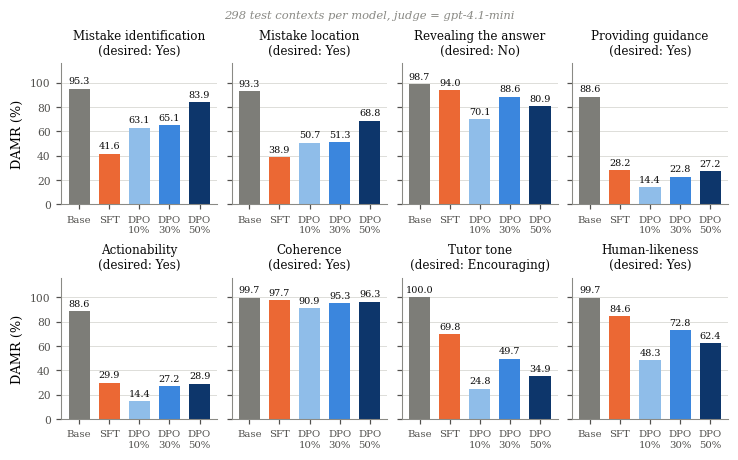

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(6.6, 3.9), sharey=True, layout="constrained")
x = np.arange(len(MODELS))
for ax, dim in zip(axes.flat, DIMS):
    values = damr.loc[dim, MODELS].to_numpy()
    bars = ax.bar(x, values, width=0.7, color=[MODEL_COLOR[m] for m in MODELS])
    label_bars(ax, bars, fmt="{:.1f}", fontsize=6.3)
    percent_axis(ax, headroom=1.16)
    ax.set_xticks(x, ["Base", "SFT", "DPO\n10%", "DPO\n30%", "DPO\n50%"], fontsize=6.6)
    ax.set_title(f"{DIM_NAMES[dim]}\n(desired: {DESIRED[dim]})", fontsize=7.8, color=INK)
    ax.tick_params(axis="y", labelsize=7)
for ax in axes[:, 0]:
    ax.set_ylabel("DAMR (%)")
scope_note(fig, "298 test contexts per model, judge = gpt-4.1-mini", y=1.01)
save(fig, "fig_5_7_damr_by_dimension")
plt.show()

#### 3. Figure 5.8 — where the non-matches go

- Full judge label distribution per dimension. First legend entry = desired label.
- Shows what DAMR hides: *To some extent* vs. *No*, *Yes (correct)* vs. *Yes (incorrect)*, *Neutral* vs. *Offensive*.

saved fig_5_8_judge_label_distribution


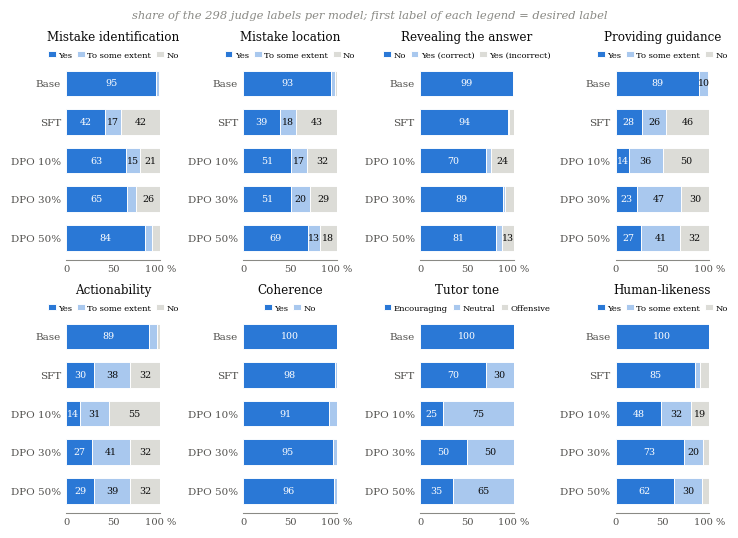

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(6.6, 4.6), layout="constrained")
y = np.arange(len(MODELS))[::-1]          # base on top
for ax, dim in zip(axes.flat, DIMS):
    counts = label_counts[dim]            # rows = labels (desired first), columns = models
    shares = 100 * counts / counts.sum(axis=0)
    left = np.zeros(len(MODELS))
    for k, label in enumerate(LABELS[dim]):
        values = shares.loc[label, MODELS].to_numpy()
        ax.barh(y, values, left=left, height=0.66, color=LABEL_COLOR[k], edgecolor="white", linewidth=0.6,
                label=label)
        # percentage inside a segment when there is room; text colour follows the segment darkness
        for yi, value, start in zip(y, values, left):
            if value >= 10:
                ax.text(start + value / 2, yi, f"{value:.0f}", ha="center", va="center", fontsize=6.2,
                        color="white" if k == 0 else INK)
        left += values
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 50, 100])
    ax.set_xticklabels(["0", "50", "100 %"], fontsize=6.5)
    ax.set_yticks(y, [MODEL_NAMES[m] for m in MODELS], fontsize=6.8)
    ax.tick_params(length=0)
    ax.spines["left"].set_visible(False)
    ax.set_title(DIM_NAMES[dim], fontsize=7.8, color=INK, pad=14)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 0.99), ncol=3, fontsize=5.5, handlelength=0.9,
              handletextpad=0.3, columnspacing=0.6, borderpad=0)
scope_note(fig, "share of the 298 judge labels per model; first label of each legend = desired label", y=1.01)
save(fig, "fig_5_8_judge_label_distribution")
plt.show()

#### 4. Figure 5.9 — DAMR within each student error type

- Rows = error types of the test split with their number of contexts (Table 4.9); columns = models.
- Small categories (15–26 contexts): one response is 4–7 percentage points.

saved fig_5_9_damr_by_error_type


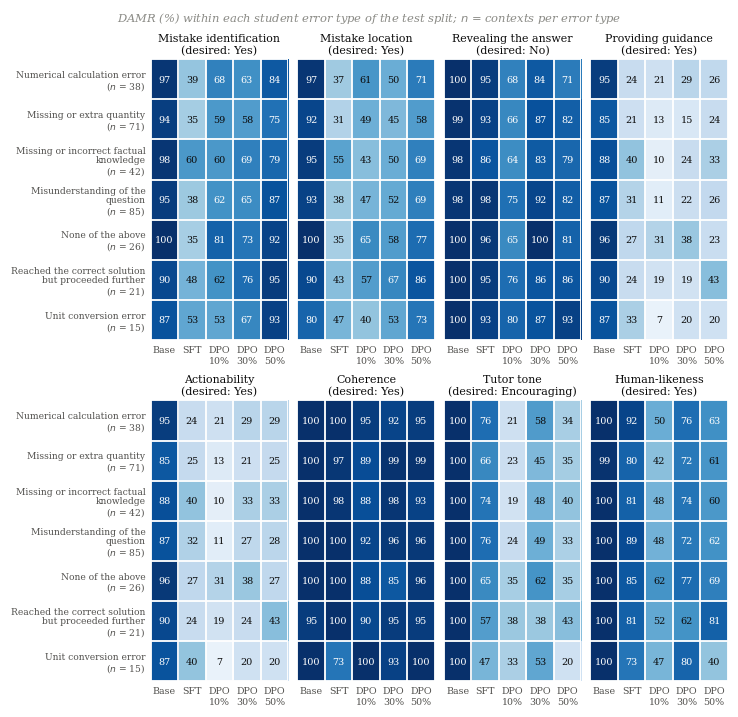

In [5]:
def error_row_label(error):
    """Full error name, wrapped, with the number of test contexts on its own line."""
    return f"{ERROR_LABELS_ROW[error]}\n($n$ = {test_counts[error]})"


def draw_damr_heatmap(ax, table, show_rows, title):
    """One dimension: rows = error types, columns = models, cell = DAMR (%)."""
    values = table.to_numpy(dtype=float)
    ax.imshow(values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(j, i, f"{values[i, j]:.0f}", ha="center", va="center", fontsize=6.3,
                    color="white" if values[i, j] > 62 else INK)
    ax.set_xticks(range(len(MODELS)), ["Base", "SFT", "DPO\n10%", "DPO\n30%", "DPO\n50%"], fontsize=6.2)
    ax.set_yticks(range(len(ERRORS)), [error_row_label(e) for e in ERRORS] if show_rows else [], fontsize=6.0, linespacing=1.0)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    # white grid between the cells
    ax.set_xticks(np.arange(-0.5, len(MODELS), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ERRORS), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", length=0)
    ax.set_title(title, fontsize=7.2, color=INK, pad=4)


fig, axes = plt.subplots(2, 4, figsize=(6.6, 6.2), layout="constrained")
for k, (ax, dim) in enumerate(zip(axes.flat, DIMS)):
    draw_damr_heatmap(ax, damr_matrix(dim), show_rows=(k % 4 == 0),
                      title=f"{DIM_NAMES[dim]}\n(desired: {DESIRED[dim]})")
scope_note(fig, "DAMR (%) within each student error type of the test split; $n$ = contexts per error type", y=1.005)
save(fig, "fig_5_9_damr_by_error_type")
plt.show()

#### 5. Figure 5.10 — change relative to SFT within each error type

- DAMR(DPO ρ) − DAMR(SFT) in percentage points; the reference policy of every DPO run is the SFT model.

saved fig_5_10_damr_change_vs_sft_by_error_type


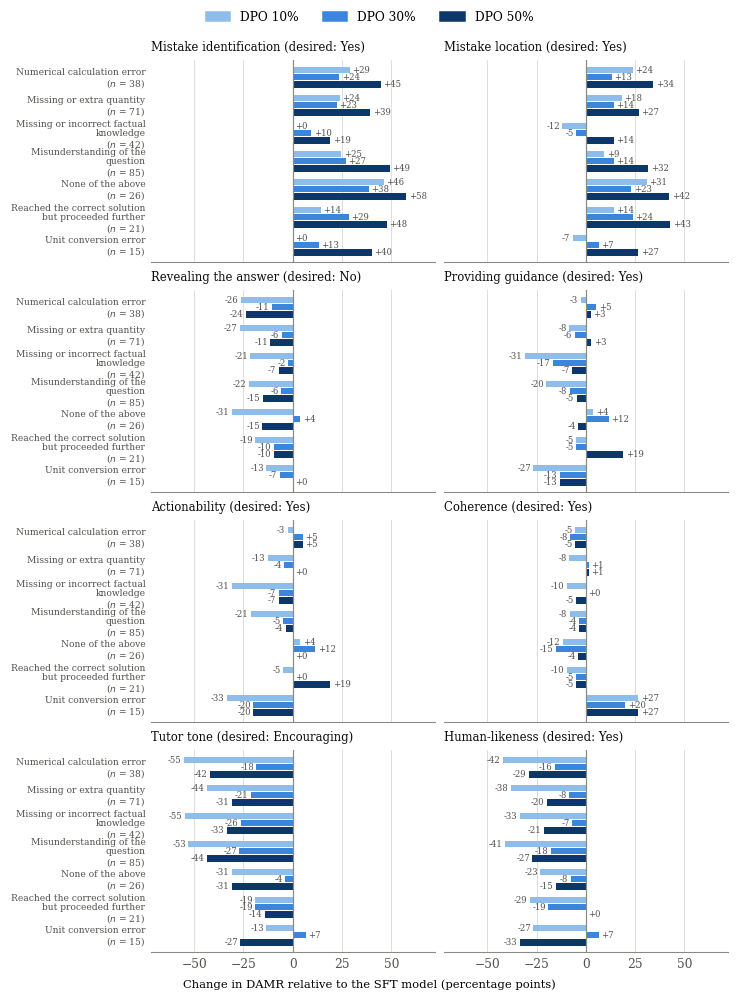

In [6]:
# change in DAMR relative to the SFT model (percentage points), per error type and rho
change_rows = []
for dim in DIMS:
    levels = damr_matrix(dim)
    for error in ERRORS:
        for model in DPO_MODELS:
            change_rows.append({"dimension": dim, "error_category": error, "model": model,
                                "damr_sft": levels.loc[error, "sft"], "damr_dpo": levels.loc[error, model],
                                "change": levels.loc[error, model] - levels.loc[error, "sft"]})
change = pd.DataFrame(change_rows)
change.to_csv(OUT / "table_damr_change_vs_sft_by_error_type.csv", index=False)


def change_matrix(dim):
    part = change[change["dimension"] == dim]
    return part.pivot(index="error_category", columns="model", values="change").loc[ERRORS, DPO_MODELS]


fig, axes = plt.subplots(4, 2, figsize=(6.6, 9.0), sharex=True, layout="constrained")
y = np.arange(len(ERRORS))[::-1]
height = 0.26
for k, (ax, dim) in enumerate(zip(axes.flat, DIMS)):
    table = change_matrix(dim)
    for j, model in enumerate(DPO_MODELS):
        values = table[model].to_numpy()
        offset = (1 - j) * height                      # rho = 0.1 on top of each group
        bars = ax.barh(y + offset, values, height=height * 0.9, color=MODEL_COLOR[model], label=MODEL_NAMES[model])
        for bar, value in zip(bars, values):
            ax.text(value + (1.2 if value >= 0 else -1.2), bar.get_y() + bar.get_height() / 2,
                    f"{value:+.0f}", ha="left" if value >= 0 else "right", va="center", fontsize=5.6, color=GREY)
    ax.axvline(0, color=PALE, lw=0.8)
    ax.set_yticks(y, [error_row_label(e) for e in ERRORS] if k % 2 == 0 else [], fontsize=6.0, linespacing=1.0)
    ax.set_ylim(-0.6, len(ERRORS) - 0.4)
    ax.tick_params(length=0)
    ax.spines["left"].set_visible(False)
    ax.set_title(f"{DIM_NAMES[dim]} (desired: {DESIRED[dim]})", fontsize=7.6, color=INK, loc="left")
    ax.grid(axis="x")
    ax.set_axisbelow(True)
ax.set_xlim(-72, 72)
fig.supxlabel("Change in DAMR relative to the SFT model (percentage points)", fontsize=7.5)
fig.legend(handles=[Patch(color=MODEL_COLOR[m], label=MODEL_NAMES[m]) for m in DPO_MODELS],
           loc="outside upper center", ncol=3)
save(fig, "fig_5_10_damr_change_vs_sft_by_error_type")
plt.show()

#### 6. Figures 5.11 and 5.12 — RQ3: the signal per error type vs. the DAMR change per error type

- Selected pairs re-derived with the rule of the DPO notebooks (top ρ share by `score_difference` within each error type); sizes must equal Table 4.8.
- Figure 5.11: mean classifier posterior of chosen minus rejected per move (Generic is ≤ 0.02 everywhere and left out); this cell draws it on all selected pairs, cell 6b on the training pairs.
- The error types are grouped by the move their selected pairs favour (largest positive shift; identical at all three ρ):
  Focus-favoured = numerical calculation error, none of the above; Telling-favoured = the other five.
- Figure 5.12: the DAMR changes of Figure 5.10 arranged by group — range of the five Telling-favoured types next to the two Focus-favoured types.
- Also printed: score margins per error type and the chosen / rejected posteriors of the ρ = 0.1 subset (misunderstanding of the question is ordered by near-zero Generic differences).

     model  rho                                   error_category  n_pairs  share_of_subset_pct  mean_score_margin  chosen_focus  rejected_focus  shift_focus  chosen_generic  rejected_generic  shift_generic  chosen_probing  rejected_probing  shift_probing  chosen_telling  rejected_telling  shift_telling
0   dpo_01  0.1  calculation_error_easily_solved_by_a_calculator      303               12.490              0.738         0.920           0.219        0.701           0.002             0.014         -0.012           0.056             0.296         -0.240           0.022             0.471         -0.449
1   dpo_01  0.1               extra_quantity_or_missing_quantity      587               24.196              0.029         0.379           0.797       -0.417           0.009             0.002          0.007           0.111             0.190         -0.079           0.501             0.011          0.490
2   dpo_01  0.1                  missing_wrong_factual_knowledge      339               

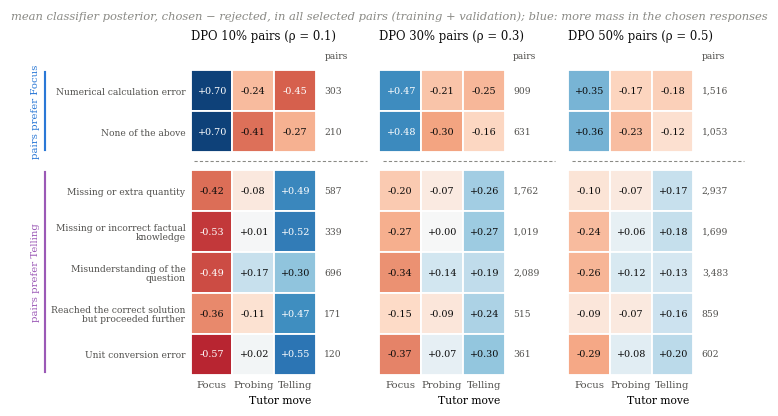

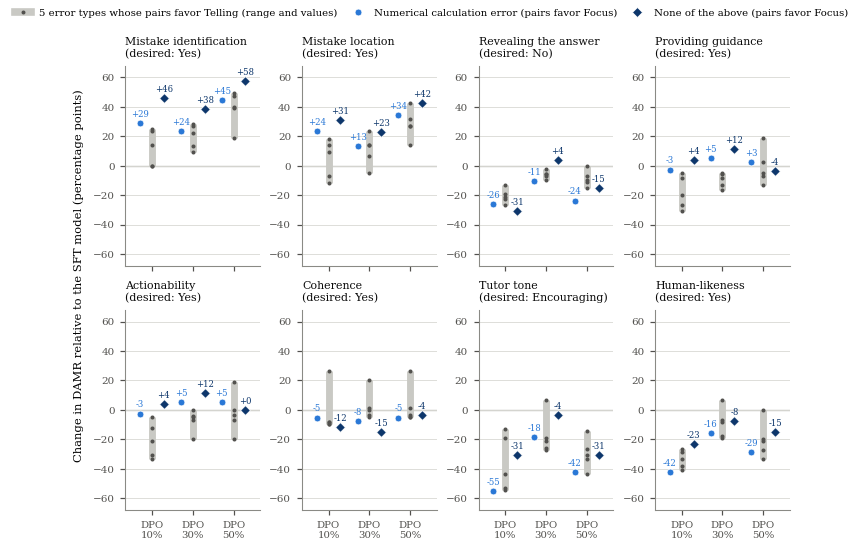

In [7]:
pairs = pd.read_csv(PAIRS_FILE)
assert len(pairs) == 24298 and pairs["context_data_idx"].nunique() == 693
assert pairs["error_category"].value_counts().reindex(ERRORS).tolist() == [3032, 5874, 3398, 6966, 2106, 1718, 1204]  # Table 4.7, in ERRORS order

# full classifier posterior of the chosen and rejected response, one column per move
import ast
for side in ["chosen", "rejected"]:
    posterior = pairs[f"{side}_label_prob_list"].map(lambda value: {d["label"]: d["probability"] for d in ast.literal_eval(value)})
    for move in MOVES:
        pairs[f"p_{side}_{move}"] = posterior.map(lambda d: d[move])
    # arg-max of the posterior is the stored hard label
    argmax = pairs[[f"p_{side}_{m}" for m in MOVES]].to_numpy().argmax(axis=1)
    assert (np.array(MOVES)[argmax] == pairs[f"{side}_label"]).all()


def select_top_pairs(df, ratio):
    """Same rule as the DPO notebooks: within each error type keep the top share of pairs by score margin."""
    kept = []
    for _, group in df.groupby("error_category"):
        group = group.sort_values("score_difference", ascending=False)
        kept.append(group.head(max(int(len(group) * ratio), 1)))
    return pd.concat(kept)


subsets = {model: select_top_pairs(pairs, RHO[model]) for model in DPO_MODELS}
assert [len(subsets[m]) for m in DPO_MODELS] == [2426, 7286, 12149]                       # Table 4.8

# per subset and error type: number of pairs and mean posterior mass per move (chosen, rejected, difference)
signal_rows = []
for model in DPO_MODELS:
    for error in ERRORS:
        group = subsets[model][subsets[model]["error_category"] == error]
        row = {"model": model, "rho": RHO[model], "error_category": error, "n_pairs": len(group),
               "share_of_subset_pct": 100 * len(group) / len(subsets[model]),
               "mean_score_margin": group["score_difference"].mean()}
        for move in MOVES:
            row[f"chosen_{move}"] = group[f"p_chosen_{move}"].mean()
            row[f"rejected_{move}"] = group[f"p_rejected_{move}"].mean()
            row[f"shift_{move}"] = row[f"chosen_{move}"] - row[f"rejected_{move}"]
        signal_rows.append(row)
signal = pd.DataFrame(signal_rows)
signal.to_csv(OUT / "table_preference_signal_by_error_type.csv", index=False)
print(signal.round(3).to_string())

# score margins per error type: all pairs vs. the selected subsets (the ordering inside an error type rests on these)
margin_rows = []
for error in ERRORS:
    all_pairs = pairs[pairs["error_category"] == error]
    row = {"error_category": error, "n_pairs": len(all_pairs),
           "median_score_difference_all": all_pairs["score_difference"].median()}
    for model in DPO_MODELS:
        row[f"mean_score_difference_{model}"] = subsets[model].loc[subsets[model]["error_category"] == error, "score_difference"].mean()
    margin_rows.append(row)
margins = pd.DataFrame(margin_rows).set_index("error_category")
margins.to_csv(OUT / "table_score_margins_by_error_type.csv")
print("\nscore margins per error type\n", margins.round(4).to_string())
print("\nmean posterior of the chosen and the rejected responses, DPO 10% subset\n",
      signal[signal["model"] == "dpo_01"].set_index("error_category")[[f"chosen_{m}" for m in MOVES] + [f"rejected_{m}" for m in MOVES]].round(3).to_string())

# --- grouping of the error types by the move their selected pairs favour ----------------------
# favoured move = move with the largest positive shift; the grouping must be the same at all three rho
SHOWN_MOVES = ["focus", "probing", "telling"]        # generic: |shift| <= 0.02 in every cell, left out of the figure
assert signal["shift_generic"].abs().max() <= 0.02
favoured = (signal.set_index(["model", "error_category"])[[f"shift_{m}" for m in SHOWN_MOVES]]
            .idxmax(axis=1).str.replace("shift_", "").unstack("model"))
assert (favoured.nunique(axis=1) == 1).all(), favoured
favoured = favoured["dpo_01"].loc[ERRORS]
FOCUS_TYPES = [e for e in ERRORS if favoured[e] == "focus"]
TELLING_TYPES = [e for e in ERRORS if favoured[e] == "telling"]
assert FOCUS_TYPES + TELLING_TYPES and len(FOCUS_TYPES) + len(TELLING_TYPES) == len(ERRORS)
print("favoured move per error type (same at every rho):\n", favoured.rename(ERROR_NAMES), "\n")
group_share = signal.assign(group=signal["error_category"].map(favoured)).groupby(["model", "group"])["n_pairs"].sum().unstack("group")
group_share["telling_pct"] = 100 * group_share["telling"] / group_share.sum(axis=1)
print("selected pairs per group\n", group_share.round(1), "\n")

# --- Figure 5.11 (all selected pairs): what the selected pairs of each error type encode ---------
# one heatmap per rho: mean posterior of the chosen minus the rejected response per move;
# rows ordered by group (Focus-favoured types first, then Telling-favoured types), gap between the groups
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
ROW_ORDER = FOCUS_TYPES + TELLING_TYPES
GAP = 0.45
row_y = {e: i + (GAP if i >= len(FOCUS_TYPES) else 0) for i, e in enumerate(ROW_ORDER)}


def preference_signal_figure(table, filename, note):
    """Grouped heatmaps of chosen-minus-rejected posterior per move; `table` has the columns of `signal`."""
    cmap, norm = plt.get_cmap("RdBu"), mcolors.Normalize(vmin=-0.75, vmax=0.75)
    fig, axes = plt.subplots(1, 3, figsize=(6.6, 3.5), layout="constrained")
    for k, model in enumerate(DPO_MODELS):
        part = table[table["model"] == model].set_index("error_category")
        ax = axes[k]
        for error in ROW_ORDER:
            y = row_y[error]
            for j, move in enumerate(SHOWN_MOVES):
                value = part.loc[error, f"shift_{move}"]
                ax.add_patch(Rectangle((j - 0.5, y - 0.5), 1, 1, facecolor=cmap(norm(value)), edgecolor="white", linewidth=1.2))
                ax.text(j, y, f"{value:+.2f}", ha="center", va="center", fontsize=6.3,
                        color="white" if abs(value) > 0.42 else INK)
            # number of pairs of the error type, as a text column right of the cells
            ax.text(len(SHOWN_MOVES) - 0.3, y, f"{int(part.loc[error, 'n_pairs']):,}", ha="left", va="center", fontsize=6, color=GREY)
        ax.text(len(SHOWN_MOVES) - 0.3, -0.85, "pairs", ha="left", va="center", fontsize=6, color=GREY)
        # separator between the two groups
        y_sep = len(FOCUS_TYPES) - 0.5 + GAP / 2
        ax.axhline(y_sep, xmin=0.02, xmax=0.98, color=PALE, lw=0.7, ls=(0, (3, 2)))
        ax.set_xlim(-0.5, len(SHOWN_MOVES) + 0.8)
        ax.set_ylim(len(ERRORS) - 0.5 + GAP, -1.1)
        ax.set_xticks(range(len(SHOWN_MOVES)), [m.title() for m in SHOWN_MOVES], fontsize=6.6)
        ax.set_yticks([row_y[e] for e in ROW_ORDER], [ERROR_LABELS_ROW[e] for e in ROW_ORDER] if k == 0 else [], fontsize=6.0, linespacing=1.0)
        ax.tick_params(length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_title(f"{MODEL_NAMES[model]} pairs (ρ = {RHO[model]})", fontsize=7.6, color=INK, loc="left", pad=4)
        ax.set_xlabel("Tutor move", fontsize=7)
    # group labels left of the row labels of the first panel (x fixed in axes fraction, left of the longest label)
    ax = axes[0]
    fig.canvas.draw()
    label_left = min(t.get_window_extent().x0 for t in ax.get_yticklabels())
    x_axes = ax.transAxes.inverted().transform((label_left, 0))[0] - 0.06
    for name, members, color in [("pairs prefer Focus", FOCUS_TYPES, MOVE_COLOR["focus"]),
                                 ("pairs prefer Telling", TELLING_TYPES, MOVE_COLOR["telling"])]:
        ys = [row_y[e] for e in members]
        trans = ax.get_yaxis_transform()          # x in axes fraction, y in data
        ax.plot([x_axes, x_axes], [min(ys) - 0.45, max(ys) + 0.45], transform=trans, color=color, lw=1.4, clip_on=False)
        ax.text(x_axes - 0.03, (min(ys) + max(ys)) / 2, name, transform=trans, rotation=90, ha="right", va="center",
                fontsize=6.6, color=color, clip_on=False)
    scope_note(fig, note, y=1.01)
    save(fig, filename)
    plt.show()


# all selected pairs (training + validation); the thesis figure is drawn on the training pairs in the next cell
preference_signal_figure(signal, "fig_5_11_preference_signal_by_error_type__all_selected_pairs",
                         "mean classifier posterior, chosen − rejected, in all selected pairs (training + validation); blue: more mass in the chosen responses")

# --- Figure 5.12: DAMR change relative to SFT, error types grouped by the favoured move -----------
# per dimension and rho: range of the Telling-favoured types (grey) next to the two Focus-favoured types (markers)
comparison_rows = []
for dim in DIMS:
    table = change_matrix(dim)
    for model in DPO_MODELS:
        row = {"dimension": dim, "model": model, "rho": RHO[model],
               "telling_types_min": table.loc[TELLING_TYPES, model].min(),
               "telling_types_max": table.loc[TELLING_TYPES, model].max()}
        for error in FOCUS_TYPES:
            row[error] = table.loc[error, model]
        comparison_rows.append(row)
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(OUT / "table_damr_change_by_favoured_move.csv", index=False)
print("change vs SFT (pp): Focus-favoured types vs range of the Telling-favoured types\n", comparison.round(1).to_string())

FOCUS_STYLE = {FOCUS_TYPES[0]: ("o", MOVE_COLOR["focus"], -0.29),
               FOCUS_TYPES[1]: ("D", "#0d366b", 0.29)}
fig, axes = plt.subplots(2, 4, figsize=(6.6, 4.9), sharex=True, layout="constrained")
x = np.arange(len(DPO_MODELS))
for k, (ax, dim) in enumerate(zip(axes.flat, DIMS)):
    table = change_matrix(dim)
    for j, model in enumerate(DPO_MODELS):
        telling = table.loc[TELLING_TYPES, model]
        ax.plot([j, j], [telling.min(), telling.max()], color="#c9c9c4", lw=4.5, solid_capstyle="butt", zorder=1)
        ax.scatter([j] * len(telling), telling, s=7, color=GREY, zorder=2, linewidths=0)
        for error, (marker, color, dx) in FOCUS_STYLE.items():
            value = table.loc[error, model]
            ax.scatter([j + dx], [value], marker=marker, s=20, color=color, zorder=3, edgecolors="white", linewidths=0.5)
            # value label above the marker (the two markers sit in their own columns, so labels never collide)
            ax.annotate(f"{value:+.0f}", (j + dx, value), xytext=(0, 3), textcoords="offset points",
                        ha="center", va="bottom", fontsize=5.6, color=color)
    ax.axhline(0, color=PALE, lw=0.8, zorder=0)
    ax.set_xlim(-0.65, len(DPO_MODELS) - 0.35)
    ax.set_ylim(-68, 68)
    ax.set_yticks(np.arange(-60, 61, 20))
    ax.tick_params(axis="y", labelsize=6.8)
    ax.set_xticks(x, ["DPO\n10%", "DPO\n30%", "DPO\n50%"], fontsize=6.6)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.set_title(f"{DIM_NAMES[dim]}\n(desired: {DESIRED[dim]})", fontsize=7.2, color=INK, loc="left")
fig.supylabel("Change in DAMR relative to the SFT model (percentage points)", fontsize=7.5)
handles = [Line2D([], [], color="#c9c9c4", lw=5, marker="o", markersize=2.6, markerfacecolor=GREY, markeredgewidth=0,
                  label=f"{len(TELLING_TYPES)} error types whose pairs favor Telling (range and values)")]
for error, (marker, color, _) in FOCUS_STYLE.items():
    handles.append(Line2D([], [], ls="", marker=marker, color=color, markersize=4.5, markeredgecolor="white", markeredgewidth=0.5,
                          label=f"{ERROR_NAMES[error]} (pairs favor Focus)"))
fig.legend(handles=handles, loc="outside upper center", ncol=3, fontsize=6.6, handlelength=1.6, columnspacing=1.2)
save(fig, "fig_5_12_damr_change_by_favoured_move")
plt.show()

#### 6b. Figure 5.11 — the DPO training pairs

- The DPO notebooks split the selected pairs 80:20 (`train_test_split`, stratified by error type, seed 42) and train on the 80 %.
- This cell reproduces that split (needs scikit-learn) and draws the thesis version of Figure 5.11 on the training pairs
  (`fig_5_11_preference_signal_by_error_type`); the previous cell keeps the all-selected version for comparison
  (`fig_5_11_preference_signal_by_error_type__all_selected_pairs`, cell differences ≤ 0.011).
- Also printed: the misunderstanding-of-the-question numbers quoted in Section 5.3.3 and the Limitations.

DPO 10%: 2,426 selected -> 1,940 training + 486 validation pairs
DPO 30%: 7,286 selected -> 5,828 training + 1,458 validation pairs
DPO 50%: 12,149 selected -> 9,719 training + 2,430 validation pairs

training pairs per group
 group   focus  telling  telling_pct
model                              
dpo_01    410     1530         78.9
dpo_03   1232     4596         78.9
dpo_05   2055     7664         78.9 

largest |training pairs - all selected pairs| per model: {'dpo_01': 0.008, 'dpo_03': 0.011, 'dpo_05': 0.006} 

                                                        n_pairs  shift_focus  shift_probing  shift_telling
model  error_category                                                                                     
dpo_01 calculation_error_easily_solved_by_a_calculator      242        0.702         -0.247         -0.441
       extra_quantity_or_missing_quantity                   469       -0.411         -0.079          0.484
       missing_wrong_factual_knowledge              

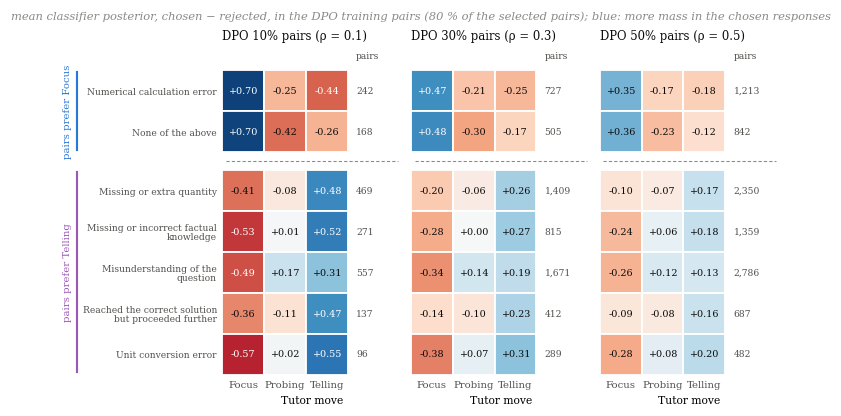

In [8]:
# --- Figure 5.11 (thesis version): the pairs the DPO models were actually trained on ---------------
# The DPO notebooks (2__SFT_DPO__/Final__DPO_DPO_DPO__{01,03,05}.ipynb) take the selected pairs of get_data_threshold
# (identical to select_top_pairs: groupby error type, score_difference descending, top rho share) and split them with
#   train_test_split(data, indices, test_size=0.20, stratify=error_category, random_state=42, shuffle=True)
# The 80 % are the DPO training pairs, the 20 % the validation pairs. The figure above uses all selected pairs;
# the thesis figure (Figure 5.11) is drawn here on the training portion only. Needs scikit-learn, like the DPO notebooks.
try:
    from sklearn.model_selection import train_test_split
    HAVE_SKLEARN = True
except ImportError:
    HAVE_SKLEARN = False
    print("scikit-learn is not installed: the training-portion figure is skipped (pip install scikit-learn to reproduce it)")


def training_portion(selected, seed=42):
    """Same split as the DPO notebooks: records in selection order, stratified 80:20, seed 42."""
    records = selected.reset_index(drop=True)          # selection order: groupby(error_category), score margin descending
    indices = list(range(len(records)))
    train_idx, val_idx = train_test_split(indices, test_size=0.20, stratify=records["error_category"].tolist(),
                                          random_state=seed, shuffle=True)
    return records.iloc[sorted(train_idx)], records.iloc[sorted(val_idx)]


if HAVE_SKLEARN:
    training = {}
    for model in DPO_MODELS:
        train_part, val_part = training_portion(subsets[model])
        training[model] = train_part
        print(f"{MODEL_NAMES[model]}: {len(subsets[model]):,} selected -> {len(train_part):,} training + {len(val_part):,} validation pairs")

    # same summary as `signal`, computed on the training pairs
    train_rows = []
    for model in DPO_MODELS:
        for error in ERRORS:
            group = training[model][training[model]["error_category"] == error]
            row = {"model": model, "rho": RHO[model], "error_category": error, "n_pairs": len(group),
                   "share_of_subset_pct": 100 * len(group) / len(training[model])}
            for move in MOVES:
                row[f"chosen_{move}"] = group[f"p_chosen_{move}"].mean()
                row[f"rejected_{move}"] = group[f"p_rejected_{move}"].mean()
                row[f"shift_{move}"] = row[f"chosen_{move}"] - row[f"rejected_{move}"]
            train_rows.append(row)
    signal_train = pd.DataFrame(train_rows)
    signal_train.to_csv(OUT / "table_preference_signal_by_error_type__training_pairs.csv", index=False)

    # the grouping must be the same as on all selected pairs
    favoured_train = (signal_train.set_index(["model", "error_category"])[[f"shift_{m}" for m in SHOWN_MOVES]]
                      .idxmax(axis=1).str.replace("shift_", "").unstack("model"))
    assert (favoured_train.nunique(axis=1) == 1).all() and (favoured_train["dpo_01"].loc[ERRORS] == favoured).all()
    group_share_train = (signal_train.assign(group=signal_train["error_category"].map(favoured))
                         .groupby(["model", "group"])["n_pairs"].sum().unstack("group"))
    group_share_train["telling_pct"] = 100 * group_share_train["telling"] / group_share_train.sum(axis=1)
    print("\ntraining pairs per group\n", group_share_train.round(1), "\n")

    key = ["model", "error_category"]
    cols = [f"shift_{m}" for m in SHOWN_MOVES]
    difference = signal_train.set_index(key)[cols] - signal.set_index(key)[cols]
    print("largest |training pairs - all selected pairs| per model:",
          difference.abs().groupby(level="model").max().max(axis=1).round(3).to_dict(), "\n")
    print(signal_train.set_index(key)[["n_pairs"] + cols].round(3).to_string())

    # numbers quoted for misunderstanding of the question (Section 5.3.3 / Limitations), on the DPO 10% training pairs
    mis = training["dpo_01"][training["dpo_01"]["error_category"] == "misunderstanding_of_a_question"]
    print(f"\nmisunderstanding of the question, DPO 10% training pairs: n = {len(mis)} ({100 * len(mis) / len(training['dpo_01']):.1f}% of the training pairs), "
          f"mean score difference = {mis['score_difference'].mean():.4f}")
    print("  mean posterior of the rejected responses:", {m: round(mis[f"p_rejected_{m}"].mean(), 2) for m in MOVES})
    print("  mean posterior of the chosen responses:  ", {m: round(mis[f"p_chosen_{m}"].mean(), 2) for m in MOVES})

    # Figure 5.11 of the thesis: the pairs the DPO models were trained on
    preference_signal_figure(signal_train, "fig_5_11_preference_signal_by_error_type",
                             "mean classifier posterior, chosen − rejected, in the DPO training pairs (80 % of the selected pairs); blue: more mass in the chosen responses")
else:
    print("WARNING: Figure 5.11 of the thesis (fig_5_11_preference_signal_by_error_type) was NOT regenerated.")

#### 7. Numbers quoted in the Section 5.3 text

In [9]:
# every number quoted in the Section 5.3 text, printed from the tables above
pd.set_option("display.width", 200)
print("DAMR (%) per dimension and model\n", damr.round(1), "\n")
print("judge label counts per dimension (rows) and model (columns)")
for dim in DIMS:
    print(f"\n{DIM_NAMES[dim]}\n", label_counts[dim])
for model in DPO_MODELS:
    print(f"\nDAMR change vs SFT (pp) per error type, {MODEL_NAMES[model]}:")
    print(change[change["model"] == model].pivot(index="error_category", columns="dimension", values="change").loc[ERRORS, DIMS].round(1))
print("\npreference signal per error type (all selected pairs)\n",
      signal.set_index(["model", "error_category"])[["n_pairs", "share_of_subset_pct", "shift_focus", "shift_probing", "shift_telling"]].round(2))
print("\nselected pairs per group of error types\n", group_share.round(1))
if HAVE_SKLEARN:
    print("\npreference signal per error type (DPO training pairs = Figure 5.11)\n",
          signal_train.set_index(["model", "error_category"])[["n_pairs", "share_of_subset_pct", "shift_focus", "shift_probing", "shift_telling"]].round(2))
    print("\ntraining pairs per group of error types\n", group_share_train.round(1))
print("\nchange vs SFT (pp): Focus-favoured types vs range of the Telling-favoured types\n",
      comparison.set_index(["dimension", "model"]).drop(columns="rho").round(1))
print("\nscore margins per error type (all pairs / selected subsets)\n", margins.round(4).to_string())

DAMR (%) per dimension and model
                          base   sft  dpo_01  dpo_03  dpo_05
mistake_identification   95.3  41.6    63.1    65.1    83.9
mistake_location         93.3  38.9    50.7    51.3    68.8
revealing_answer         98.7  94.0    70.1    88.6    80.9
providing_guidance       88.6  28.2    14.4    22.8    27.2
actionability            88.6  29.9    14.4    27.2    28.9
coherence                99.7  97.7    90.9    95.3    96.3
tutor_tone              100.0  69.8    24.8    49.7    34.9
human_likeness           99.7  84.6    48.3    72.8    62.4 

judge label counts per dimension (rows) and model (columns)

Mistake identification
                               base  sft  dpo_01  dpo_03  dpo_05
mistake_identification_label                                   
Yes                            284  124     188     194     250
To some extent                  10   50      46      28      21
No                               4  124      64      76      27

Mistake location
 

#### A. Supplementary — training behaviour (not part of Section 5.3)

- Kept for reference only: SFT cross-entropy, DPO loss, reward accuracy and implicit reward margin per selection ratio, from the trainer logs.
- Outputs: the figure `fig_A1_training_behaviour` and the table `table_A1_training_final_validation` (CSV).

model                            SFT  DPO 10%   DPO 30%   DPO 50%
optimisation steps          1521.000  366.000  1095.000  1824.000
validation loss                1.806    0.440     0.478     0.512
validation token accuracy      0.552    0.593     0.595     0.586
validation reward accuracy       NaN    0.802     0.764     0.748
validation reward margin         NaN    1.361     1.015     0.816
validation reward chosen         NaN    0.655     0.224    -0.112
validation reward rejected       NaN   -0.706    -0.791    -0.927
saved fig_A1_training_behaviour


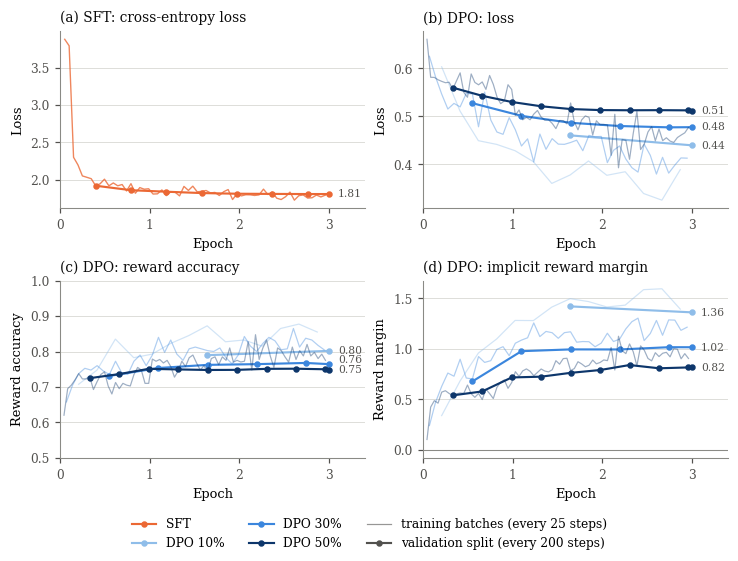

In [10]:
logs = {}
for model, path in TRAINER_STATE.items():
    state = json.loads(Path(path).read_text())
    history = pd.DataFrame(state["log_history"])
    logs[model] = {
        "train": history[history["loss"].notna()].copy(),            # every 25 steps
        "eval": history[history["eval_loss"].notna()].copy(),        # every 200 steps + end of training
        "global_step": state["global_step"],
        "epochs": state["num_train_epochs"],
    }
    assert logs[model]["eval"]["epoch"].iloc[-1] == 3.0            # every run finished its three epochs

# final validation values (end of epoch 3) for Table 5.2
rows = []
for model in TRAINER_STATE:
    last = logs[model]["eval"].iloc[-1]
    rows.append({
        "model": MODEL_NAMES[model],
        "optimisation steps": logs[model]["global_step"],
        "validation loss": round(last["eval_loss"], 3),
        "validation token accuracy": round(last["eval_mean_token_accuracy"], 3),
        "validation reward accuracy": round(last.get("eval_rewards/accuracies", np.nan), 3),
        "validation reward margin": round(last.get("eval_rewards/margins", np.nan), 3),
        "validation reward chosen": round(last.get("eval_rewards/chosen", np.nan), 3),
        "validation reward rejected": round(last.get("eval_rewards/rejected", np.nan), 3),
    })
training_table = pd.DataFrame(rows).set_index("model")
training_table.to_csv(OUT / "table_A1_training_final_validation.csv")
print(training_table.T)

def end_labels(ax, values, fmt="{:.2f}", x=3.1, min_gap=None):
    """Final validation values written to the right of the last markers, pushed apart when they would overlap."""
    values = list(values)
    if min_gap is None:
        low, high = ax.get_ylim()
        min_gap = 0.055 * (high - low)
    positions = np.array(values, dtype=float)
    order = np.argsort(positions)
    for previous, current in zip(order[:-1], order[1:]):
        if positions[current] - positions[previous] < min_gap:
            positions[current] = positions[previous] + min_gap
    for value, position in zip(values, positions):
        ax.annotate(fmt.format(value), (x, position), ha="left", va="center", fontsize=7, color=GREY)


# --- Figure: training behaviour -------------------------------------------
# sized for the text width; thin lines = training batches, markers = validation split
fig, axes = plt.subplots(2, 2, figsize=(6.6, 5.0), layout="constrained")
axes = axes.flat

ax = axes[0]
sft = logs["sft"]
ax.plot(sft["train"]["epoch"], sft["train"]["loss"], color=MODEL_COLOR["sft"], lw=0.9, alpha=0.8)
ax.plot(sft["eval"]["epoch"], sft["eval"]["eval_loss"], color=MODEL_COLOR["sft"], lw=1.4, marker="o", ms=3.2)
end_labels(ax, [sft["eval"]["eval_loss"].iloc[-1]])
ax.set_title("(a) SFT: cross-entropy loss", loc="left", color=INK)
ax.set_ylabel("Loss")

panels = [
    (axes[1], "loss", "eval_loss", "(b) DPO: loss", "Loss"),
    (axes[2], "rewards/accuracies", "eval_rewards/accuracies", "(c) DPO: reward accuracy", "Reward accuracy"),
    (axes[3], "rewards/margins", "eval_rewards/margins", "(d) DPO: implicit reward margin", "Reward margin"),
]
for ax, train_key, eval_key, title, ylabel in panels:
    for model in DPO_MODELS:
        run = logs[model]
        ax.plot(run["train"]["epoch"], run["train"][train_key], color=MODEL_COLOR[model], lw=0.8, alpha=0.4)
        ax.plot(run["eval"]["epoch"], run["eval"][eval_key], color=MODEL_COLOR[model], lw=1.4, marker="o", ms=3.2)
    ax.set_title(title, loc="left", color=INK)
    ax.set_ylabel(ylabel)
axes[2].set_ylim(0.5, 1.0)
for ax, _, eval_key, _, _ in panels:
    end_labels(ax, [logs[m]["eval"][eval_key].iloc[-1] for m in DPO_MODELS])
axes[3].axhline(0, color=PALE, lw=0.7)
for ax in axes:
    ax.set_xlim(0, 3.4)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xlabel("Epoch")
    ax.grid(axis="y")
    ax.set_axisbelow(True)

handles = [Line2D([], [], color=MODEL_COLOR["sft"], lw=1.4, marker="o", ms=3.2, label="SFT")]
handles += [Line2D([], [], color=MODEL_COLOR[m], lw=1.4, marker="o", ms=3.2, label=MODEL_NAMES[m]) for m in DPO_MODELS]
handles += [Line2D([], [], color=GREY, lw=0.8, alpha=0.6, label="training batches (every 25 steps)"),
            Line2D([], [], color=GREY, lw=1.4, marker="o", ms=3.2, label="validation split (every 200 steps)")]
fig.legend(handles=handles, loc="outside lower center", ncol=3)
save(fig, "fig_A1_training_behaviour")
plt.show()